In [2]:
pip install geopandas

  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ----- ---------------------------------- 3.1/22.9 MB 16.0 MB/s eta 0:00:02
   ------------ --------------------------- 7.1/22.9 MB 17.3 MB/s eta 0:00:01
   -------------------- ------------------- 11.5/22.9 MB 19.0 MB/s eta 0:00:01
   ----------------------------- ---------- 16.8/22.9 MB 19.9 MB/s eta 0:00:01
   ----------------------------------- ---- 20.2/22.9 MB 19.2 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 18.0 MB/s  0:00:01
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   -------------------------- ------------- 4.2/6.3 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 17.9 MB/s  0:00:00

   ---------------------------------------- 0/3 [pyproj]
   ---------------------------------------- 0/3 [pyproj]
   --


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install overturemaps


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install duckdb

   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   --------- ------------------------------ 3.1/13.1 MB 16.6 MB/s eta 0:00:01
   ------------------- -------------------- 6.6/13.1 MB 17.0 MB/s eta 0:00:01
   ------------------------------- -------- 10.2/13.1 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------- 13.1/13.1 MB 16.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install folium


   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Querying Overture Maps S3 Parquet for Washington Avenue segments...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Error querying Overture Maps: Expected bytes or string, got bytearray
Using fallback mock data for Washington Avenue.
Total number of segments: 3
Total length of Washington Ave segments: 5226.2 meters
CRS of GeoDataFrame: EPSG:4326


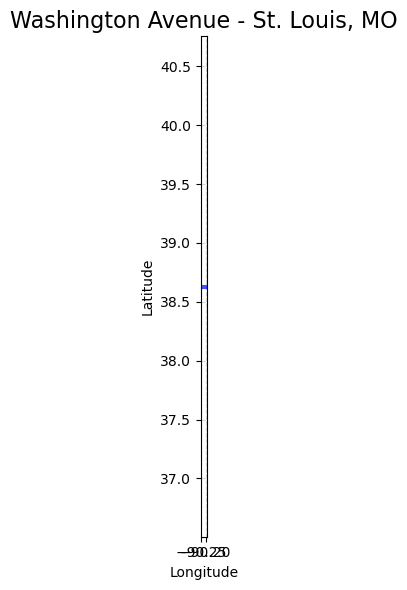

Interactive map saved to washington_ave_map.html

--- Washington Avenue Segment Summary ---
      id            name     length_m
0  mock1  Washington Ave  1742.056427
1  mock2  Washington Ave  1742.074439
2  mock3  Washington Ave  1742.092582
Total length (meters): 5226.2
Dissolved geometry type: MultiLineString


C:\Users\geppe\AppData\Local\Temp\ipykernel_2484\3328536213.py:155: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = [gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()]


In [13]:
# washington_ave_duckdb_geopandas.py

# =========================
# Required pip installs:
# pip install duckdb geopandas shapely folium matplotlib pyarrow
# =========================

import duckdb
import geopandas as gpd
import pandas as pd
import shapely
from shapely.geometry import LineString
import matplotlib.pyplot as plt
import folium
import sys
import os

# --- Constants and Parameters ---

# Overture Maps S3 Parquet path (2026 release)
OVERTURE_S3_PATH = (
    "s3://overturemaps-us-west-2/release/2026-04-15.0/theme=transportation/type=segment/*"
)

# Bounding box for Washington Avenue, St. Louis, MO
BBOX = {
    "xmin": -90.25,
    "xmax": -90.19,
    "ymin": 38.62,
    "ymax": 38.64,
}



# UTM zone 15N for St. Louis (for metric length calculations)
CRS_METRIC = "EPSG:32615"
CRS_WGS84 = "EPSG:4326"

#gdf = gdf.to_crs(epsg=3857)  # Reproject to Web Mercator

# --- Helper: Fallback Mock Data ---

def create_mock_washington_ave_gdf():
    """
    Create a mock GeoDataFrame simulating Washington Avenue segments.
    """
    # Simulate 3 segments along Washington Ave
    lines = [
        LineString([(-90.25, 38.63), (-90.23, 38.63)]),
        LineString([(-90.23, 38.63), (-90.21, 38.63)]),
        LineString([(-90.21, 38.63), (-90.19, 38.63)]),
    ]
    data = {
        "id": ["mock1", "mock2", "mock3"],
        "name": ["Washington Ave"] * 3,
        "geometry": lines,
        "class": ["primary"] * 3,
        "subtype": ["road"] * 3,
    }
    gdf = gpd.GeoDataFrame(data, geometry="geometry", crs=CRS_WGS84)
    return gdf

# --- Main Data Extraction and Processing ---

def fetch_washington_ave_segments():
    """
    Query Overture Maps S3 Parquet for Washington Avenue road segments using DuckDB.
    Returns a GeoDataFrame or None if query fails.
    """
    try:
        # Connect to DuckDB and load required extensions
        con = duckdb.connect()
        con.execute("INSTALL httpfs; LOAD httpfs;")
        con.execute("INSTALL spatial; LOAD spatial;")

        # SQL query: filter by bounding box and road name
        query = f"""
        SELECT
            id,
            names.primary AS name,
            geometry,
            class,
            subtype,
            bbox
        FROM
            read_parquet('{OVERTURE_S3_PATH}')
        WHERE
            subtype = 'road'
            AND bbox.xmin <= {BBOX['xmax']}
            AND bbox.xmax >= {BBOX['xmin']}
            AND bbox.ymin <= {BBOX['ymax']}
            AND bbox.ymax >= {BBOX['ymin']}
            AND names.primary ILIKE '%Washington%'
        """

        print("Querying Overture Maps S3 Parquet for Washington Avenue segments...")
        df = con.execute(query).df()
        if df.empty:
            print("No segments found in Overture Maps for Washington Avenue.")
            return None

        # Convert WKB geometry to shapely objects
        gdf = gpd.GeoDataFrame(
            df,
            geometry=gpd.GeoSeries.from_wkb(df["geometry"]),
            crs=CRS_WGS84,
        )
        print(f"Retrieved {len(gdf)} segments from Overture Maps.")
        return gdf

    except Exception as e:
        print(f"Error querying Overture Maps: {e}")
        return None

# --- Spatial Analysis ---

def analyze_segments(gdf):
    """
    Compute segment lengths (in meters), total length, and dissolve all segments.
    """
    # Reproject to UTM for accurate metric calculations
    gdf_metric = gdf.to_crs(CRS_METRIC)
    gdf["length_m"] = gdf_metric.geometry.length

    total_length = gdf["length_m"].sum()
    dissolved = gdf.dissolve()  # Dissolve all segments into one geometry

    print(f"Total number of segments: {len(gdf)}")
    print(f"Total length of Washington Ave segments: {total_length:.1f} meters")
    print(f"CRS of GeoDataFrame: {gdf.crs}")
    return gdf, total_length, dissolved

# --- Visualization: Matplotlib ---

def plot_segments(gdf, title="Washington Avenue - St. Louis, MO"):
    """
    Plot all segments using matplotlib.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    gdf.plot(ax=ax, color="blue", linewidth=3, alpha=0.7)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- Visualization: Folium Interactive Map ---

def folium_map(gdf, html_path="washington_ave_map.html"):
    """
    Create an interactive folium map and save as HTML.
    """
    # Center map on Washington Ave
    center = [gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()]
    fmap = folium.Map(location=center, zoom_start=15, tiles="cartodbpositron")

    for _, row in gdf.iterrows():
        coords = [(lat, lon) for lon, lat in row.geometry.coords]
        folium.PolyLine(
            coords,
            color="blue",
            weight=5,
            opacity=0.8,
            tooltip=row.get("name", "Washington Ave"),
        ).add_to(fmap)

    fmap.save(html_path)
    print(f"Interactive map saved to {html_path}")

# --- Main Program ---

def main():
    # Step 1: Try to fetch real Overture Maps data
    gdf = fetch_washington_ave_segments()

    # Step 2: Fallback to mock data if needed
    if gdf is None or gdf.empty:
        print("Using fallback mock data for Washington Avenue.")
        gdf = create_mock_washington_ave_gdf()

    # Step 3: Spatial analysis
    gdf, total_length, dissolved = analyze_segments(gdf)

    # Step 4: Visualization
    plot_segments(gdf)
    folium_map(gdf)

    # Step 5: Print summary
    print("\n--- Washington Avenue Segment Summary ---")
    print(gdf[["id", "name", "length_m"]])
    print(f"Total length (meters): {total_length:.1f}")
    print("Dissolved geometry type:", dissolved.geometry.iloc[0].geom_type)

if __name__ == "__main__":
    main()


In [56]:
!set PYTHONIOENCODING=utf-8

In [65]:
!overturemaps download \
  --bbox=-90.21135,38.63004,-90.19229,38.63517 \
  -f geojson \
  --type=place \
  -o washington_ave_map_b.geojson


Error reading STAC index at https://stac.overturemaps.org/2026-04-15.0/collections.parquet: Repetition level histogram size mismatch


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\geppe\anaconda3\Scripts\overturemaps.exe\__main__.py", line 6, in <module>
    sys.exit(cli())
             ~~~^^
  File "C:\Users\geppe\anaconda3\Lib\site-packages\click\core.py", line 1514, in __call__
    return self.main(*args, **kwargs)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "C:\Users\geppe\anaconda3\Lib\site-packages\click\core.py", line 1435, in main
    rv = self.invoke(ctx)
  File "C:\Users\geppe\anaconda3\Lib\site-packages\click\core.py", line 1902, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
                           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^
  File "C:\Users\geppe\anaconda3\Lib\site-packages\click\core.py", line 1298, in invoke
    return ctx.invoke(self.callback, **ctx.params)
           ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\geppe\anaconda3\Lib\site-packages\cli

In [34]:
pip install gpxpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import gpxpy
import geopandas as gpd
from shapely.geometry import Point

# Parse the GPX file
with open("C:\\Users\\geppe\\hackathon\\Apr_25,_2026_4_56_38_PM.gpx", "r") as gpx_file:
    gpx = gpxpy.parse(gpx_file)

# Extract track points and convert to GeoDataFrame
points = []
for track in gpx.tracks:
    for segment in track.segments:
        for point in segment.points:
            points.append(Point(point.longitude, point.latitude))

# Create a GeoDataFrame with the original CRS (WGS84 - EPSG:4326)
gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")

# Reproject the GeoDataFrame to a CRS that uses feet
# Example: EPSG:2272 (NAD83 / Pennsylvania South (ftUS))
gdf = gdf.to_crs(epsg=2272)

# Verify the new CRS
print("Reprojected CRS:", gdf.crs)

# Example: Perform a buffer operation in feet (e.g., 50 feet)
gdf["geometry"] = gdf["geometry"].buffer(100)

# Save or inspect the updated GeoDataFrame
gdf = gdf.to_crs(epsg="4326")

gdf.to_file("buffer100.geojson")


Reprojected CRS: EPSG:2272


In [81]:
# Save or inspect the updated GeoDataFrame
gdf = gdf.to_crs(epsg="4326")

gdf.to_file("buffer100.geojson")


In [84]:
%ls

 Volume in drive C is OS
 Volume Serial Number is CC02-E9E2

 Directory of C:\Users\geppe

04/25/2026  09:50 PM    <DIR>          .
01/31/2025  01:59 AM    <DIR>          ..
03/30/2025  04:20 PM    <DIR>          .anaconda
09/08/2024  07:48 PM    <DIR>          .azuredatastudio
04/11/2026  05:56 PM    <DIR>          .cache
04/25/2026  08:33 PM    <DIR>          .conda
03/30/2025  10:56 PM               163 .condarc
03/30/2025  04:14 PM    <DIR>          .continuum
05/27/2025  10:24 AM    <DIR>          .dbus-keyrings
04/25/2026  02:20 PM    <DIR>          .duckdb
04/25/2026  04:04 PM    <DIR>          .ipynb_checkpoints
03/30/2025  11:06 PM    <DIR>          .ipython
03/30/2025  10:50 PM    <DIR>          .jupyter
04/20/2025  03:40 PM    <DIR>          .matplotlib
02/15/2026  10:53 PM    <DIR>          .Neo4jDesktop2
04/11/2026  05:53 PM               249 .python_history
03/01/2026  03:43 PM    <DIR>          .redis-insight
03/30/2025  11:06 PM                 0 .Rhistory
01/18/2026  1

In [87]:
buffer = "buffer100.geojson"
washing = "hackathon\washington_ave.geojson"

import os
assert os.path.exists(washing)

import geopandas as gpd

buffer_gdf = gpd.read_file(buffer)
buffer_washing = gpd.read_file(washing)

inter = gpd.sjoin(buffer_gdf, buffer_washing, predicate="intersects", how="inner")



C:\Users\geppe\anaconda3\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'addresses' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


In [89]:
unique = inter.drop_duplicates(subset="id")
unique.to_file("intersect100.geojson")
